# E-Commerce Marketing Analytics Project
## End-to-End Exploratory Analysis & Customer Satisfaction Prediction


**Project:** E-Commerce Marketplace Marketing Analytics  
**Analysis Period:** September 2016 – October 2018  

### Business Context
The project analyzes an e-commerce marketplace using customer, seller, product, order, payment, review, and geolocation data. The report is designed to:

- understand overall business performance;
- examine customer, seller, product, payment, and review behavior;
- identify trends and commercially useful patterns;
- prepare a clean analytical dataset;
- build and compare multiple machine-learning classification models; and
- identify operational factors associated with customer satisfaction.

### Predictive Objective
For the machine-learning extension, an order is classified as:

- **Satisfied = 1** when `review_score >= 4`
- **Not Satisfied = 0** when `review_score < 4`

# 1. Analysis Workflow

The notebook follows the complete analytics lifecycle:

Business Understanding → Data Loading → Basic Exploration → Data Quality → Cleaning → EDA → Data Integration → Feature Engineering → Train/Test Split → Preprocessing → Model Building → Prediction → Evaluation → Cross-Validation → Hyperparameter Tuning → Feature Importance → Summary

### Algorithms Compared
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree
5. Bagging Classifier
6. Random Forest
7. XGBoost

In [1]:
# Cell 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


# 2. Load the Data

In [2]:
# Cell 2: File paths and data loading

customers = pd.read_csv("CUSTOMERS.csv")
orders = pd.read_csv("ORDERS.csv")
order_items = pd.read_csv("ORDER_ITEMS.csv")
payments = pd.read_csv("ORDER_PAYMENTS.csv")
reviews = pd.read_csv("ORDER_REVIEW_RATINGS.csv")
products = pd.read_csv("PRODUCTS.csv")
sellers = pd.read_csv("SELLERS.csv")
geo = pd.read_csv("GEO_LOCATION.csv")

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geo Location": geo
}

print("All datasets loaded successfully.")


All datasets loaded successfully.


# 3. Basic Data Exploration

In [3]:
# Cell 3: Dataset dimensions

shape_summary = pd.DataFrame(
    [(name, df.shape[0], df.shape[1]) for name, df in datasets.items()],
    columns=["Dataset", "Rows", "Columns"]
)

display(shape_summary)

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Order Items,112650,7
3,Payments,103886,5
4,Reviews,100000,5
5,Products,32951,9
6,Sellers,3095,4
7,Geo Location,19015,5


In [4]:
# Cell 4: Preview each dataset

for name, df in datasets.items():
    print("\n" + "=" * 90)
    print(name.upper())
    print("=" * 90)
    display(df.head())



CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,Adilabad,Andhra Pradesh
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,Adoni,Andhra Pradesh
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,Akkarampalle,Andhra Pradesh
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,Akkayapalle,Andhra Pradesh
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,Alwal,Andhra Pradesh



ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00



ORDER ITEMS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,Perfumery,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,Sports_Leisure,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,Baby,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,Housewares,37.00,402.00,4.00,625.00,20.00,17.00,13.00



SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,Alwal,Andhra Pradesh
1,d1b65fc7debc3361ea86b5f14c68d2e2,13023,Alwal,Andhra Pradesh
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,Badepalle,Andhra Pradesh
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,Akkarampalle,Andhra Pradesh
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,Koratla,Andhra Pradesh



GEO LOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,Akkarampalle,Andhra Pradesh
1,1046,-23.55,-46.64,Akkarampalle,Andhra Pradesh
2,1041,-23.54,-46.64,Akkarampalle,Andhra Pradesh
3,1035,-23.54,-46.64,Akkarampalle,Andhra Pradesh
4,1012,-23.55,-46.64,Akkarampalle,Andhra Pradesh


In [5]:
# Cell 5: Column names and data types

for name, df in datasets.items():
    print("\n" + "=" * 90)
    print(name.upper())
    print("=" * 90)
    display(pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values
    }))



CUSTOMERS


,Column,Data Type
0,customer_id,object
1,customer_unique_id,object
2,customer_zip_code_prefix,int64
3,customer_city,object
4,customer_state,object



ORDERS


,Column,Data Type
0,order_id,object
1,customer_id,object
2,order_status,object
3,order_purchase_timestamp,object
4,order_approved_at,object
5,order_delivered_carrier_date,object
6,order_delivered_customer_date,object
7,order_estimated_delivery_date,object



ORDER ITEMS


...

,Column,Data Type
0,product_id,object
1,product_category_name,object
2,product_name_lenght,float64
3,product_description_lenght,float64
4,product_photos_qty,float64
5,product_weight_g,float64
6,product_length_cm,float64
7,product_height_cm,float64
8,product_width_cm,float64



SELLERS


,Column,Data Type
0,seller_id,object
1,seller_zip_code_prefix,int64
2,seller_city,object
3,seller_state,object



GEO LOCATION


,Column,Data Type
0,geolocation_zip_code_prefix,int64
1,geolocation_lat,float64
2,geolocation_lng,float64
3,geolocation_city,object
4,geolocation_state,object


In [6]:
# Cell 6: Statistical summaries

for name, df in datasets.items():
    print("\n" + "=" * 90)
    print(name.upper())
    print("=" * 90)
    display(df.describe(include="all").T)



CUSTOMERS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,274fa6071e5e17fe303b9748641082c8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,"99,441.00",NaN,NaN,NaN,"35,137.47","29,797.94","1,003.00","11,347.00","24,416.00","58,900.00","99,990.00"
customer_city,99441,4119,Akkarampalle,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,20,Andhra Pradesh,60688,NaN,NaN,NaN,NaN,NaN,NaN,NaN



ORDERS


,count,unique,top,freq
order_id,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1
customer_id,99441,99441,edb027a75a1449115f6b43211ae02a24,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,88789,8/2/2018 12:06,28
order_approved_at,99281,50462,1/10/2018 10:32,109
order_delivered_carrier_date,97658,61544,5/9/2018 15:48,47
order_delivered_customer_date,96476,75649,7/24/2018 18:28,7
order_estimated_delivery_date,99441,459,12/20/2017 0:00,522



ORDER ITEMS


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,106392145fca363410d287a815be6de4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32328,71,Bed_Bath_Table,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,"32,341.00",NaN,NaN,NaN,48.48,10.25,5.00,42.00,51.00,57.00,76.00
product_description_lenght,"32,341.00",NaN,NaN,NaN,771.50,635.12,4.00,339.00,595.00,972.00,"3,992.00"
product_photos_qty,"32,341.00",NaN,NaN,NaN,2.19,1.74,1.00,1.00,1.00,3.00,20.00
product_weight_g,"32,949.00",NaN,NaN,NaN,"2,276.47","4,282.04",0.00,300.00,700.00,"1,900.00","40,425.00"
product_length_cm,"32,949.00",NaN,NaN,NaN,30.82,16.91,7.00,18.00,25.00,38.00,105.00
product_height_cm,"32,949.00",NaN,NaN,NaN,16.94,13.64,2.00,8.00,13.00,21.00,105.00
product_width_cm,"32,949.00",NaN,NaN,NaN,23.20,12.08,6.00,15.00,20.00,30.00,118.00



SELLERS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,9e25199f6ef7e7c347120ff175652c3b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,"3,095.00",NaN,NaN,NaN,"32,174.79","32,656.67","1,001.00","7,084.00","14,940.00","61,780.00","99,730.00"
seller_city,3038,534,Akkarampalle,699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3038,19,Andhra Pradesh,2060,NaN,NaN,NaN,NaN,NaN,NaN,NaN



GEO LOCATION


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,"19,015.00",NaN,NaN,NaN,"42,711.59","30,905.05","1,001.00","12,721.50","38,240.00","70,656.50","99,990.00"
geolocation_lat,"19,015.00",NaN,NaN,NaN,-19.06,7.32,-36.61,-23.56,-22.43,-15.62,42.18
geolocation_lng,"19,015.00",NaN,NaN,NaN,-46.06,5.38,-72.93,-49.00,-46.63,-43.26,121.11
geolocation_city,19015,3809,Akkarampalle,5889,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,19015,20,Andhra Pradesh,11218,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4. Data Quality Assessment


In [7]:
# Cell 7: Missing-value report

missing_reports = []

for name, df in datasets.items():
    temp = pd.DataFrame({
        "Dataset": name,
        "Column": df.columns,
        "Missing_Count": df.isna().sum().values,
        "Missing_Percentage": (df.isna().mean().values * 100)
    })
    missing_reports.append(temp)

missing_report = pd.concat(missing_reports, ignore_index=True)
missing_report = missing_report[missing_report["Missing_Count"] > 0]
display(missing_report.sort_values(["Dataset", "Missing_Percentage"], ascending=[True, False]))


,Dataset,Column,Missing_Count,Missing_Percentage
11,Orders,order_delivered_customer_date,2965,2.98
10,Orders,order_delivered_carrier_date,1783,1.79
9,Orders,order_approved_at,160,0.16
31,Products,product_category_name,623,1.89
32,Products,product_name_lenght,610,1.85
33,Products,product_description_lenght,610,1.85
34,Products,product_photos_qty,610,1.85
35,Products,product_weight_g,2,0.01
36,Products,product_length_cm,2,0.01
37,Products,product_height_cm,2,0.01


In [8]:
# Cell 8: Duplicate-row check

duplicate_summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Duplicate_Rows": [df.duplicated().sum() for df in datasets.values()]
})

display(duplicate_summary)


,Dataset,Duplicate_Rows
0,Customers,0
1,Orders,0
2,Order Items,0
3,Payments,0
4,Reviews,0
5,Products,0
6,Sellers,0
7,Geo Location,0


# 5. Data Cleaning

In [9]:
# Cell 9: Convert date columns

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

for col in ["review_creation_date", "review_answer_timestamp"]:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

if "shipping_limit_date" in order_items.columns:
    order_items["shipping_limit_date"] = pd.to_datetime(
        order_items["shipping_limit_date"], errors="coerce"
    )

print("Date conversion completed.")


Date conversion completed.


In [10]:
# Cell 10: Clean product and seller data

if "product_category_name" in products.columns:
    products["product_category_name"] = products["product_category_name"].fillna("Unknown")

product_numeric_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in product_numeric_cols:
    if col in products.columns:
        products[col] = products[col].fillna(products[col].median())

for col in ["seller_city", "seller_state"]:
    if col in sellers.columns:
        sellers[col] = sellers[col].fillna("Unknown")

print("Basic cleaning completed.")


Basic cleaning completed.


# 6. High-Level Business Metrics


In [11]:
# Cell 11: Management KPI summary

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Item Revenue",
        "Total Items Sold",
        "Total Orders",
        "Unique Customers",
        "Total Products",
        "Total Categories",
        "Total Sellers",
        "Payment Methods"
    ],
    "Value": [
        order_items["price"].sum(),
        len(order_items),
        orders["order_id"].nunique(),
        customers["customer_unique_id"].nunique(),
        products["product_id"].nunique(),
        products["product_category_name"].nunique(),
        sellers["seller_id"].nunique(),
        payments["payment_type"].nunique()
    ]
})

display(kpi_summary)


,Metric,Value
0,Total Item Revenue,"13,591,643.70"
1,Total Items Sold,"112,650.00"
2,Total Orders,"99,441.00"
3,Unique Customers,"96,096.00"
4,Total Products,"32,951.00"
5,Total Categories,72.00
6,Total Sellers,"3,095.00"
7,Payment Methods,5.00


# 7. Exploratory Data Analysis


,Order Status,Orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


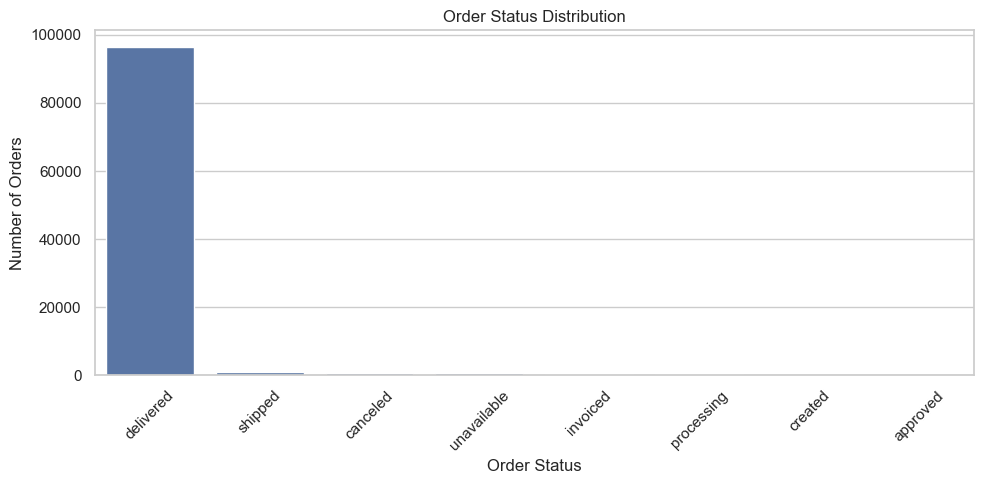

In [12]:
# Cell 12: Order-status distribution

order_status = orders["order_status"].value_counts().reset_index()
order_status.columns = ["Order Status", "Orders"]
display(order_status)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,Reviews
review_score,
1,11858
2,3235
3,8287
4,19200
5,57420


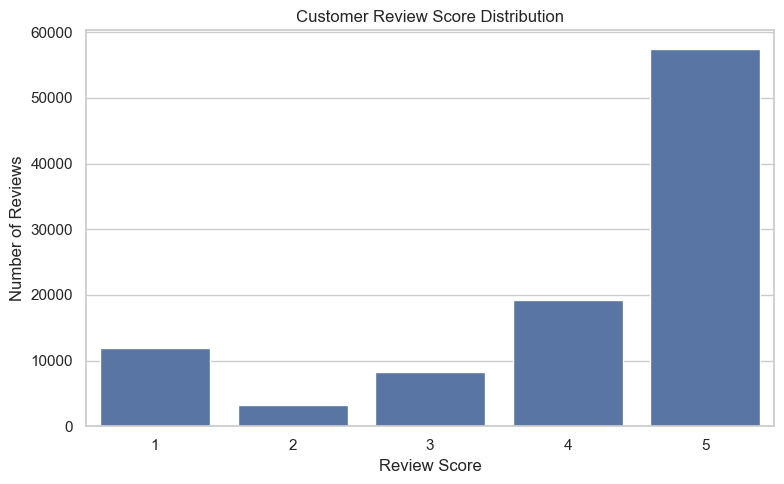

In [13]:
# Cell 13: Review-score distribution

review_distribution = reviews["review_score"].value_counts().sort_index()
display(review_distribution.to_frame("Reviews"))

plt.figure(figsize=(8, 5))
sns.countplot(data=reviews, x="review_score")
plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


,Transactions,Total_Payment,Average_Payment
payment_type,,,
credit_card,76795,"12,542,084.19",163.32
UPI,19784,"2,869,361.27",145.03
voucher,5775,"379,436.87",65.70
debit_card,1529,"217,989.79",142.57
not_defined,3,0.00,0.00


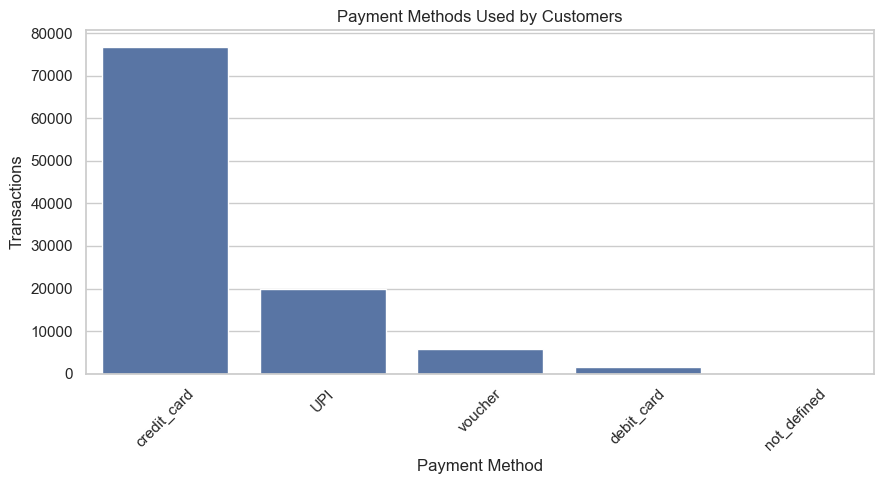

In [14]:
# Cell 14: Payment behavior

payment_summary = (
    payments.groupby("payment_type")
    .agg(
        Transactions=("order_id", "count"),
        Total_Payment=("payment_value", "sum"),
        Average_Payment=("payment_value", "mean")
    )
    .sort_values("Total_Payment", ascending=False)
)

display(payment_summary)

plt.figure(figsize=(9, 5))
sns.countplot(
    data=payments,
    x="payment_type",
    order=payments["payment_type"].value_counts().index
)
plt.title("Payment Methods Used by Customers")
plt.xlabel("Payment Method")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 8. Building an Order-Level Analytical Dataset

In [15]:
# Cell 15: Aggregate order items

item_order = (
    order_items.groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        total_item_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

display(item_order.head())


,order_id,item_count,total_item_price,total_freight,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [16]:
# Cell 16: Aggregate payments and identify main payment type

payment_order = (
    payments.groupby("order_id")
    .agg(
        total_payment=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_count=("payment_sequential", "count")
    )
    .reset_index()
)

main_payment = (
    payments.sort_values(["order_id", "payment_value"], ascending=[True, False])
    .drop_duplicates("order_id")[["order_id", "payment_type"]]
)

payment_order = payment_order.merge(main_payment, on="order_id", how="left")
display(payment_order.head())


,order_id,total_payment,payment_installments,payment_count,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [17]:
# Cell 17: Aggregate reviews

review_order = (
    reviews.groupby("order_id")
    .agg(review_score=("review_score", "mean"))
    .reset_index()
)

display(review_order.head())


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.00
1,00018f77f2f0320c557190d7a144bdd3,4.00
2,000229ec398224ef6ca0657da4fc703e,5.00
3,00024acbcdf0a6daa1e931b038114c75,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00


In [18]:
# Cell 18: Create master order-level dataset

master = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(item_order, on="order_id", how="left")
    .merge(payment_order, on="order_id", how="left")
    .merge(review_order, on="order_id", how="left")
)

print("Master dataset shape:", master.shape)
display(master.head())


Master dataset shape: (99441, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,total_item_price,total_freight,unique_products,unique_sellers,total_payment,payment_installments,payment_count,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,Akkarampalle,Andhra Pradesh,1.00,29.99,8.72,1.00,1.00,38.71,1.00,3.00,voucher,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,af07308b275d755c9edb36a90c618231,47813,Pandariya,Chhattisgarh,1.00,118.70,22.76,1.00,1.00,141.46,1.00,1.00,UPI,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,Dhamdha,Chhattisgarh,1.00,159.90,19.22,1.00,1.00,179.12,3.00,1.00,credit_card,5.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,Kartarpur,Punjab,1.00,45.00,27.20,1.00,1.00,72.20,1.00,1.00,credit_card,5.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,Bheemavaram,Andhra Pradesh,1.00,19.90,8.72,1.00,1.00,28.62,1.00,1.00,credit_card,5.00


# 9. Feature Engineering


In [19]:
# Cell 19: Time and delivery features

master["purchase_year"] = master["order_purchase_timestamp"].dt.year
master["purchase_month"] = master["order_purchase_timestamp"].dt.month
master["purchase_day"] = master["order_purchase_timestamp"].dt.day
master["purchase_dayofweek"] = master["order_purchase_timestamp"].dt.dayofweek
master["purchase_hour"] = master["order_purchase_timestamp"].dt.hour
master["year_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)

master["actual_delivery_days"] = (
    master["order_delivered_customer_date"] - master["order_purchase_timestamp"]
).dt.total_seconds() / 86400

master["estimated_delivery_days"] = (
    master["order_estimated_delivery_date"] - master["order_purchase_timestamp"]
).dt.total_seconds() / 86400

master["delivery_delay_days"] = (
    master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

master["is_late"] = (master["delivery_delay_days"] > 0).astype(int)

display(master.head())


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,total_item_price,total_freight,unique_products,unique_sellers,total_payment,payment_installments,payment_count,payment_type,review_score,purchase_year,purchase_month,purchase_day,purchase_dayofweek,purchase_hour,year_month,actual_delivery_days,estimated_delivery_days,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,Akkarampalle,Andhra Pradesh,1.00,29.99,8.72,1.00,1.00,38.71,1.00,3.00,voucher,4.00,2017,10,2,0,10,2017-10,8.44,15.54,-7.11,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,af07308b275d755c9edb36a90c618231,47813,Pandariya,Chhattisgarh,1.00,118.70,22.76,1.00,1.00,141.46,1.00,1.00,UPI,4.00,2018,7,24,1,20,2018-07,13.78,19.14,-5.36,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,Dhamdha,Chhattisgarh,1.00,159.90,19.22,1.00,1.00,179.12,3.00,1.00,credit_card,5.00,2018,8,8,2,8,2018-08,9.39,26.64,-17.25,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,Kartarpur,Punjab,1.00,45.00,27.20,1.00,1.00,72.20,1.00,1.00,credit_card,5.00,2017,11,18,5,19,2017-11,13.21,26.19,-12.98,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,Bheemavaram,Andhra Pradesh,1.00,19.90,8.72,1.00,1.00,28.62,1.00,1.00,credit_card,5.00,2018,2,13,1,21,2018-02,2.87,12.11,-9.24,0


# 10. Revenue and Order Trends


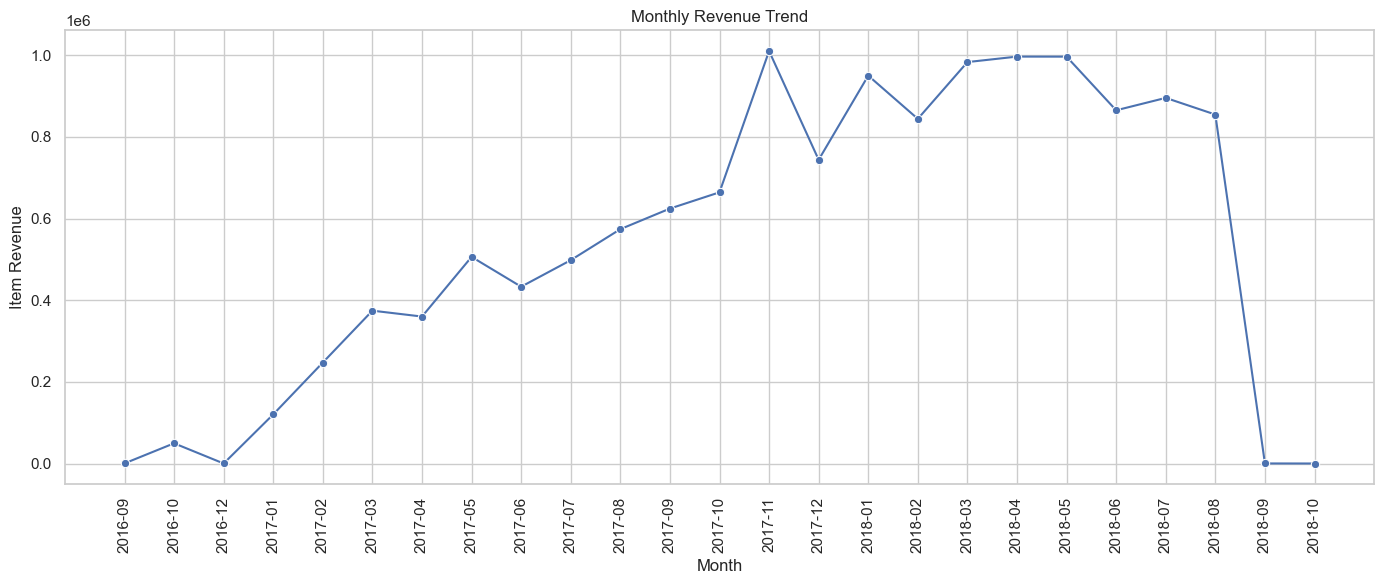

,year_month,total_item_price
0,2016-09,267.36
1,2016-10,"49,507.66"
2,2016-12,10.90
3,2017-01,"120,312.87"
4,2017-02,"247,303.02"
5,2017-03,"374,344.30"
6,2017-04,"359,927.23"
7,2017-05,"506,071.14"
8,2017-06,"433,038.60"
9,2017-07,"498,031.48"


In [20]:
# Cell 20: Monthly revenue

monthly_sales = (
    master.groupby("year_month", as_index=False)["total_item_price"].sum()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="year_month", y="total_item_price", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Item Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(monthly_sales)


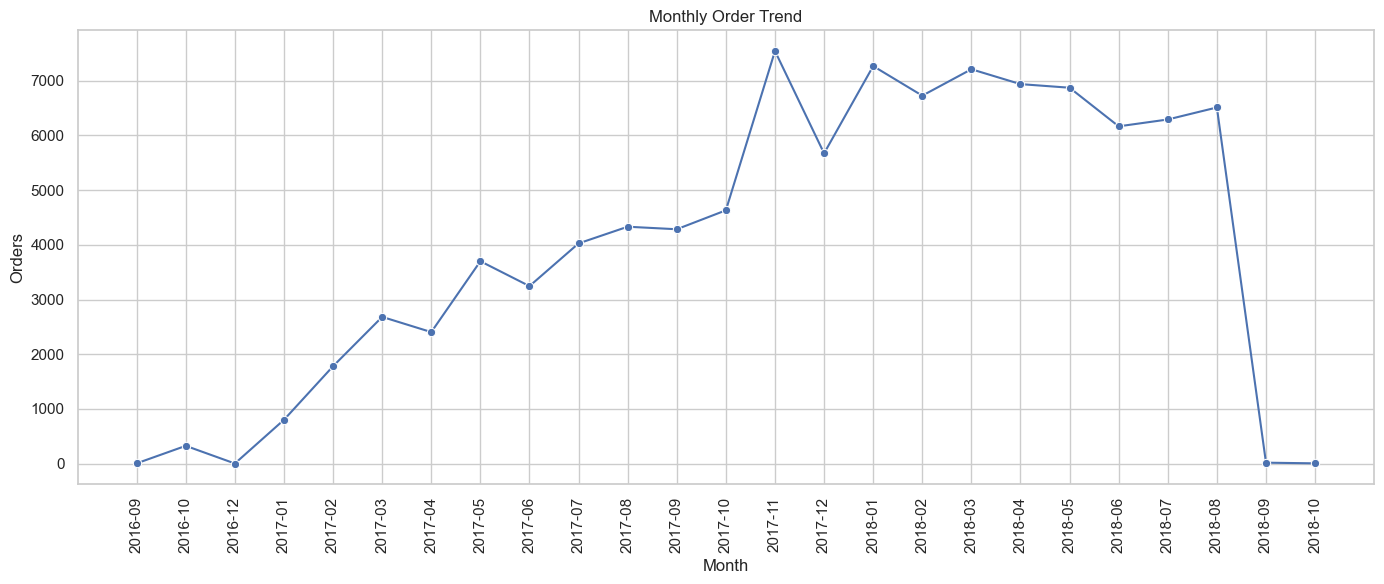

In [21]:
# Cell 21: Monthly order trend

monthly_orders = (
    master.groupby("year_month")["order_id"]
    .nunique()
    .reset_index(name="orders")
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_orders, x="year_month", y="orders", marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# 11. Product and Category Analysis


,Revenue
product_category_name,
Health_Beauty,"1,258,681.34"
Watches_Gifts,"1,205,005.68"
Bed_Bath_Table,"1,036,988.68"
Sports_Leisure,"988,048.97"
Computers_Accessories,"911,954.32"
Furniture_Decor,"729,762.49"
Cool_Stuff,"635,290.85"
Housewares,"632,248.66"
Auto,"592,720.11"


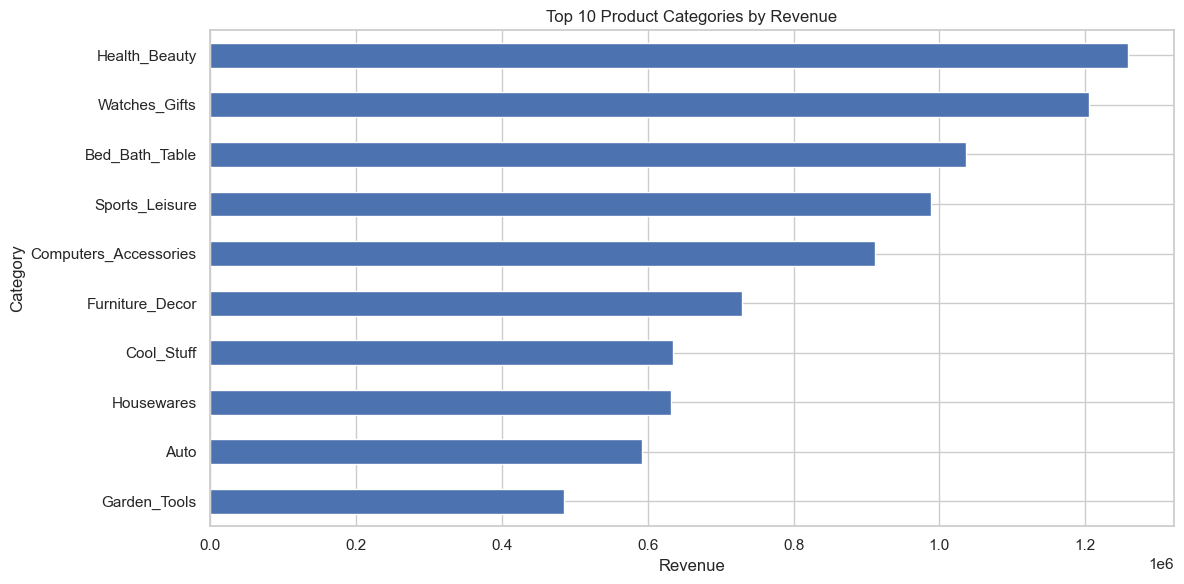

In [22]:
# Cell 22: Product-level sales table

product_sales = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_revenue = (
    product_sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(category_revenue.to_frame("Revenue"))

plt.figure(figsize=(12, 6))
category_revenue.sort_values().plot(kind="barh")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [23]:
# Cell 23: Top 10 most expensive products

top_expensive = (
    order_items[["product_id", "price"]]
    .drop_duplicates("product_id")
    .sort_values("price", ascending=False)
    .head(10)
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
)

display(top_expensive)


,product_id,price,product_category_name
0,489ae2aa008f021502940f251d4cce7f,"6,735.00",Housewares
1,69c590f7ffc7bf8db97190b6cb6ed62e,"6,729.00",Computers
2,1bdf5e6731585cf01aa8169c7028d6ad,"6,499.00",Art
3,a6492cc69376c469ab6f61d8f44de961,"4,799.00",Small_Appliances
4,c3ed642d592594bb648ff4a04cee2747,"4,690.00",Small_Appliances
5,259037a6a41845e455183f89c5035f18,"4,590.00",Computers
6,a1beef8f3992dbd4cd8726796aa69c53,"4,399.87",Musical_Instruments
7,6cdf8fc1d741c76586d8b6b15e9eef30,"4,099.99",Consoles_Games
8,6902c1962dd19d540807d0ab8fade5c6,"3,999.90",Watches_Gifts
9,4ca7b91a31637bd24fb8e559d5e015e4,"3,999.00",Small_Appliances


# 12. Customer Acquisition and Revenue Segmentation


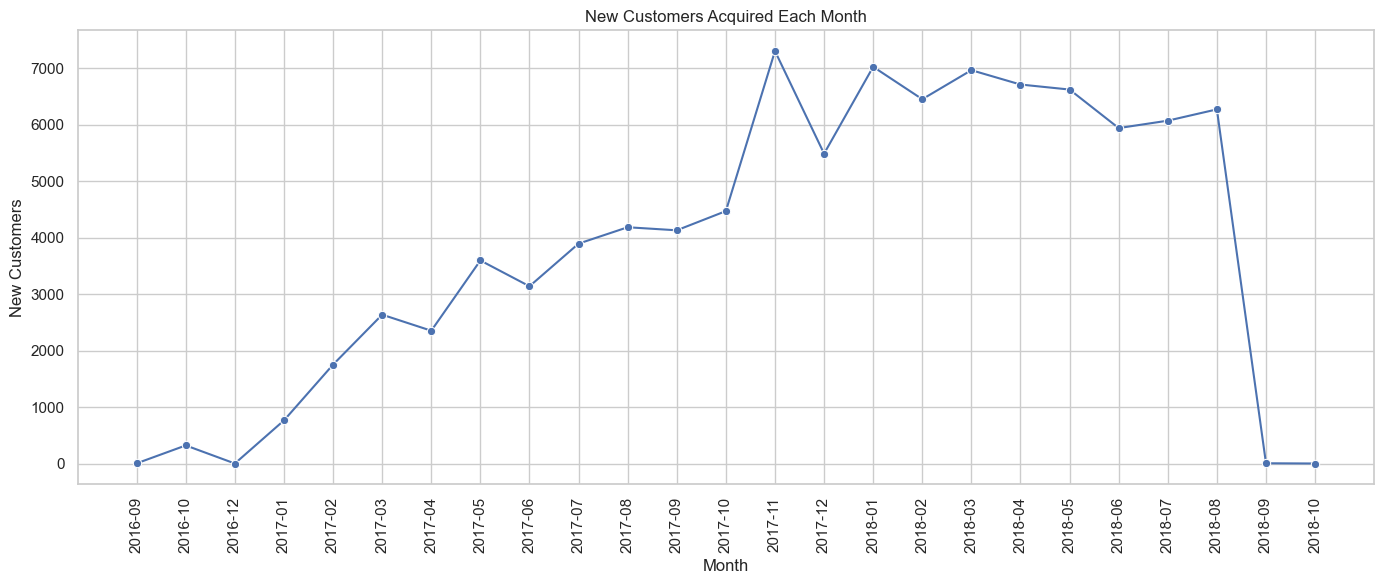

,acquisition_month,new_customers
0,2016-09,4
1,2016-10,321
2,2016-12,1
3,2017-01,764
4,2017-02,1752
5,2017-03,2636
6,2017-04,2352
7,2017-05,3596
8,2017-06,3139
9,2017-07,3894


In [24]:
# Cell 24: New customers acquired by month

first_purchase = (
    master.groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase["acquisition_month"] = (
    first_purchase["order_purchase_timestamp"].dt.to_period("M").astype(str)
)

new_customers_monthly = (
    first_purchase.groupby("acquisition_month")
    .size()
    .reset_index(name="new_customers")
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=new_customers_monthly,
    x="acquisition_month",
    y="new_customers",
    marker="o"
)
plt.title("New Customers Acquired Each Month")
plt.xlabel("Month")
plt.ylabel("New Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(new_customers_monthly)


In [25]:
# Cell 25: Customer revenue segmentation

customer_revenue = (
    master.groupby("customer_unique_id")["total_item_price"]
    .sum()
    .reset_index(name="customer_revenue")
)

customer_revenue["segment"] = pd.qcut(
    customer_revenue["customer_revenue"],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "Very High Value"],
    duplicates="drop"
)

display(customer_revenue["segment"].value_counts().to_frame("Customers"))


,Customers
segment,
Medium Value,24100
Low Value,24027
Very High Value,24007
High Value,23962


# 13. Predictive Modelling — Customer Satisfaction

### Target Definition
The classification target is created from the review score:

- `1`: review score of 4 or 5 — satisfied
- `0`: review score below 4 — not satisfied

,Count,Percentage
is_satisfied,,
1,76173,76.60
0,23268,23.40


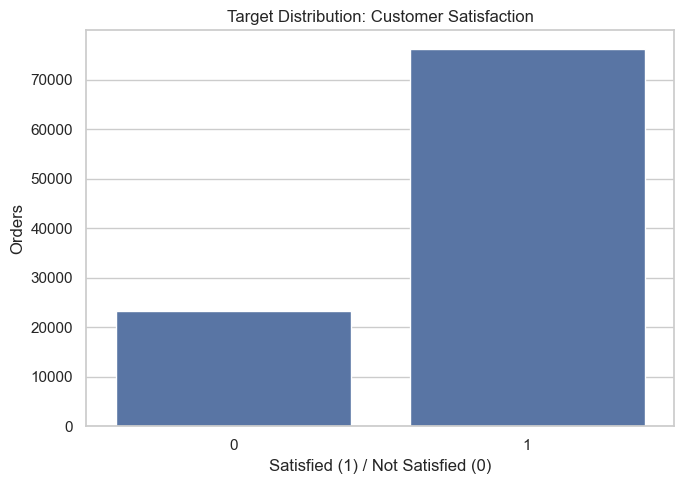

In [26]:
# Cell 26: Create modelling target

ml_data = master.dropna(subset=["review_score"]).copy()
ml_data["is_satisfied"] = (ml_data["review_score"] >= 4).astype(int)

target_summary = pd.DataFrame({
    "Count": ml_data["is_satisfied"].value_counts(),
    "Percentage": ml_data["is_satisfied"].value_counts(normalize=True) * 100
})

display(target_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=ml_data, x="is_satisfied")
plt.title("Target Distribution: Customer Satisfaction")
plt.xlabel("Satisfied (1) / Not Satisfied (0)")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()


In [27]:
# Cell 27: Select predictors

features = [
    "item_count",
    "total_item_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "total_payment",
    "payment_installments",
    "payment_count",
    "actual_delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "payment_type",
    "customer_state"
]

X = ml_data[features].copy()
y = ml_data["is_satisfied"].copy()

print("Predictor matrix:", X.shape)
print("Target vector:", y.shape)
display(X.head())


Predictor matrix: (99441, 17)
Target vector: (99441,)


,item_count,total_item_price,total_freight,unique_products,unique_sellers,total_payment,payment_installments,payment_count,actual_delivery_days,estimated_delivery_days,delivery_delay_days,is_late,purchase_month,purchase_dayofweek,purchase_hour,payment_type,customer_state
0,1.00,29.99,8.72,1.00,1.00,38.71,1.00,3.00,8.44,15.54,-7.11,0,10,0,10,voucher,Andhra Pradesh
1,1.00,118.70,22.76,1.00,1.00,141.46,1.00,1.00,13.78,19.14,-5.36,0,7,1,20,UPI,Chhattisgarh
2,1.00,159.90,19.22,1.00,1.00,179.12,3.00,1.00,9.39,26.64,-17.25,0,8,2,8,credit_card,Chhattisgarh
3,1.00,45.00,27.20,1.00,1.00,72.20,1.00,1.00,13.21,26.19,-12.98,0,11,5,19,credit_card,Punjab
4,1.00,19.90,8.72,1.00,1.00,28.62,1.00,1.00,2.87,12.11,-9.24,0,2,1,21,credit_card,Andhra Pradesh


# 14. Train/Test Split and Preprocessing


In [28]:
# Cell 28: Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training predictors:", X_train.shape)
print("Testing predictors :", X_test.shape)
print("Training target    :", y_train.shape)
print("Testing target     :", y_test.shape)


Training predictors: (79552, 17)
Testing predictors : (19889, 17)
Training target    : (79552,)
Testing target     : (19889,)


In [29]:
# Cell 29: Build preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Compatibility across scikit-learn versions
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['item_count', 'total_item_price', 'total_freight', 'unique_products', 'unique_sellers', 'total_payment', 'payment_installments', 'payment_count', 'actual_delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late', 'purchase_month', 'purchase_dayofweek', 'purchase_hour']
Categorical features: ['payment_type', 'customer_state']


# 15. Model Evaluation Framework

In [30]:
# Cell 30: Reusable evaluation function

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

results = []

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }
    results.append(metrics)

    print("=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return pipeline


# 16. Logistic Regression


Logistic Regression
              precision    recall  f1-score   support

           0       0.44      0.47      0.45      4654
           1       0.83      0.82      0.83     15235

    accuracy                           0.74     19889
   macro avg       0.64      0.64      0.64     19889
weighted avg       0.74      0.74      0.74     19889



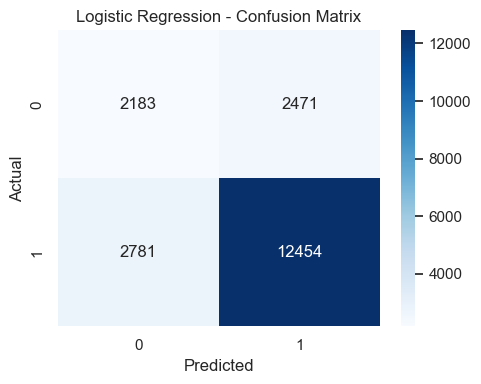

In [31]:
# Cell 31: Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

logistic_model = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_train, X_test, y_train, y_test
)


# 17. K-Nearest Neighbors


KNN
              precision    recall  f1-score   support

           0       0.55      0.28      0.37      4654
           1       0.81      0.93      0.87     15235

    accuracy                           0.78     19889
   macro avg       0.68      0.61      0.62     19889
weighted avg       0.75      0.78      0.75     19889



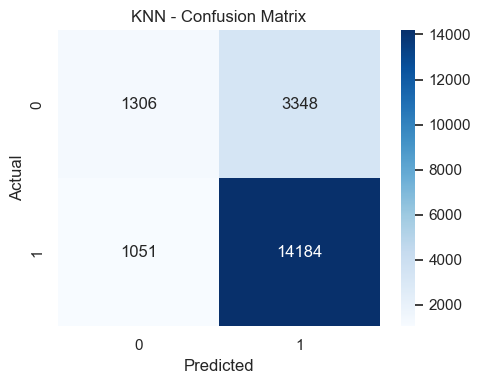

In [32]:
# Cell 32: KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model = evaluate_model(
    "KNN",
    knn_model,
    X_train, X_test, y_train, y_test
)


# 18. Naive Bayes


Naive Bayes
              precision    recall  f1-score   support

           0       0.57      0.29      0.39      4654
           1       0.81      0.93      0.87     15235

    accuracy                           0.78     19889
   macro avg       0.69      0.61      0.63     19889
weighted avg       0.75      0.78      0.76     19889



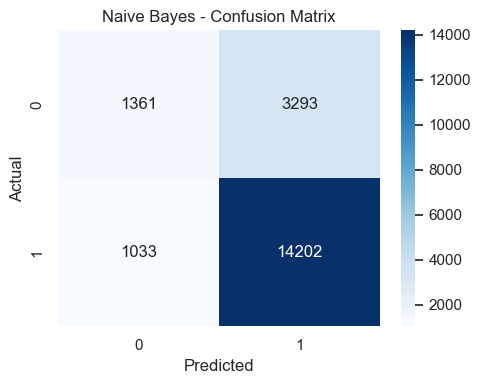

In [33]:
# Cell 33: Gaussian Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

nb_model = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train, X_test, y_train, y_test
)


# 19. Decision Tree


Decision Tree
              precision    recall  f1-score   support

           0       0.51      0.48      0.49      4654
           1       0.84      0.86      0.85     15235

    accuracy                           0.77     19889
   macro avg       0.68      0.67      0.67     19889
weighted avg       0.77      0.77      0.77     19889



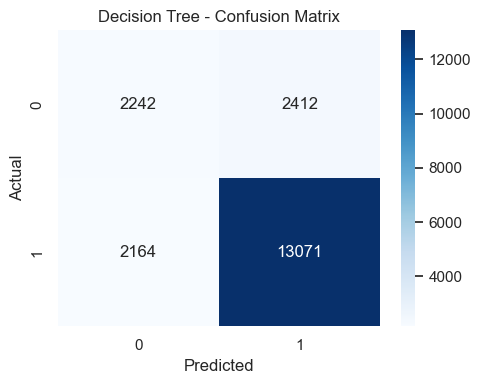

In [34]:
# Cell 34: Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        class_weight="balanced"
    ))
])

dt_model = evaluate_model(
    "Decision Tree",
    dt_model,
    X_train, X_test, y_train, y_test
)


# 20. Bagging Classifier


Bagging
              precision    recall  f1-score   support

           0       0.75      0.34      0.47      4654
           1       0.83      0.97      0.89     15235

    accuracy                           0.82     19889
   macro avg       0.79      0.65      0.68     19889
weighted avg       0.81      0.82      0.79     19889



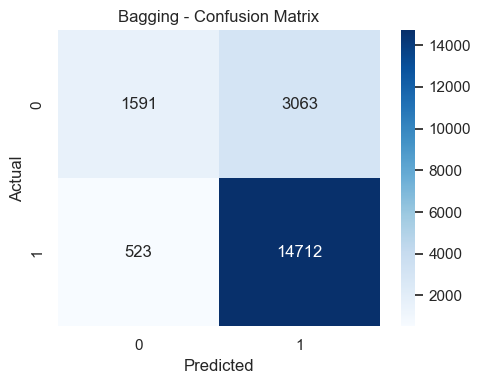

In [35]:
# Cell 35: Bagging

from sklearn.ensemble import BaggingClassifier

bagging_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

bagging_model = evaluate_model(
    "Bagging",
    bagging_model,
    X_train, X_test, y_train, y_test
)


# 21. Random Forest


Random Forest
              precision    recall  f1-score   support

           0       0.62      0.43      0.51      4654
           1       0.84      0.92      0.88     15235

    accuracy                           0.80     19889
   macro avg       0.73      0.67      0.69     19889
weighted avg       0.79      0.80      0.79     19889



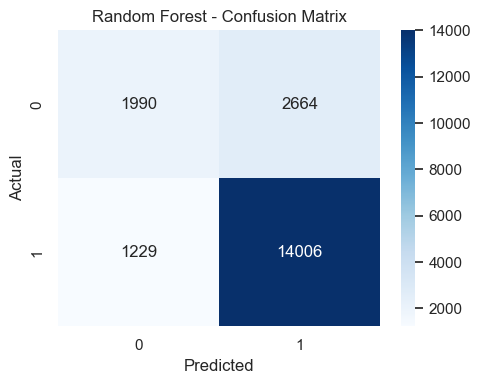

In [36]:
# Cell 36: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model = evaluate_model(
    "Random Forest",
    rf_model,
    X_train, X_test, y_train, y_test
)


# 22. XGBoost


XGBoost
              precision    recall  f1-score   support

           0       0.78      0.33      0.46      4654
           1       0.83      0.97      0.89     15235

    accuracy                           0.82     19889
   macro avg       0.81      0.65      0.68     19889
weighted avg       0.82      0.82      0.79     19889



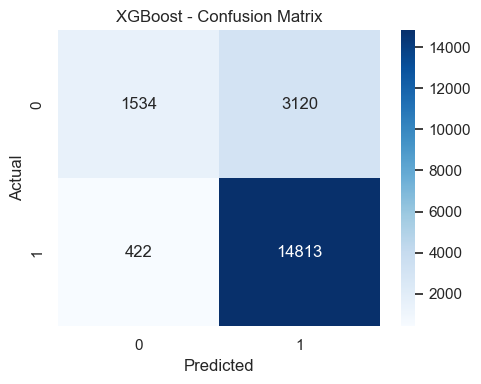

In [37]:
# Cell 37: XGBoost


try:
    from xgboost import XGBClassifier

    xgb_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_model = evaluate_model(
        "XGBoost",
        xgb_model,
        X_train, X_test, y_train, y_test
    )
except ImportError:
    xgb_model = None
    print("XGBoost is not installed. Run: pip install xgboost")

# 23. Model Comparison


In [38]:
# Cell 38: Compare all models

results_df = (
    pd.DataFrame(results)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.822,0.826,0.972,0.893,0.731
1,Bagging,0.820,0.828,0.966,0.891,0.708
2,Random Forest,0.804,0.840,0.919,0.878,0.726
3,Naive Bayes,0.782,0.812,0.932,0.868,0.646
4,KNN,0.779,0.809,0.931,0.866,0.643
5,Decision Tree,0.770,0.844,0.858,0.851,0.710
6,Logistic Regression,0.736,0.834,0.817,0.826,0.683


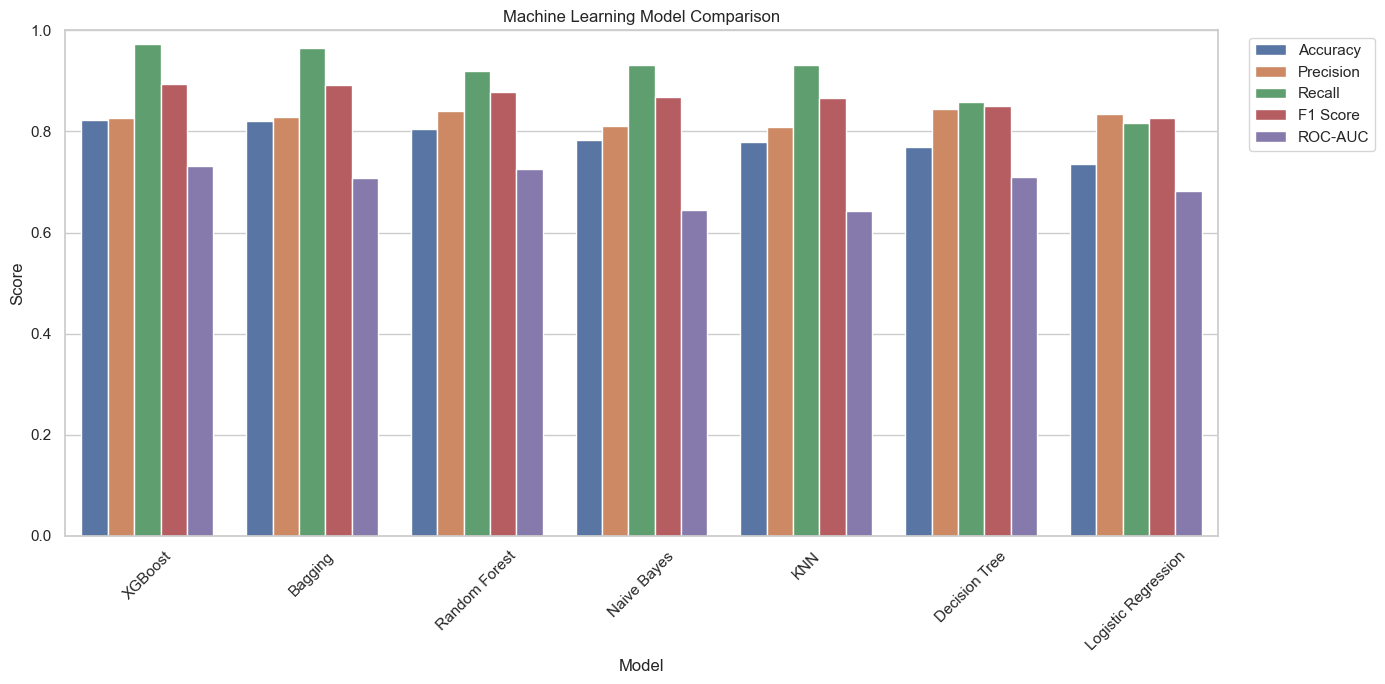

In [39]:
# Cell 39: Visual model comparison

plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


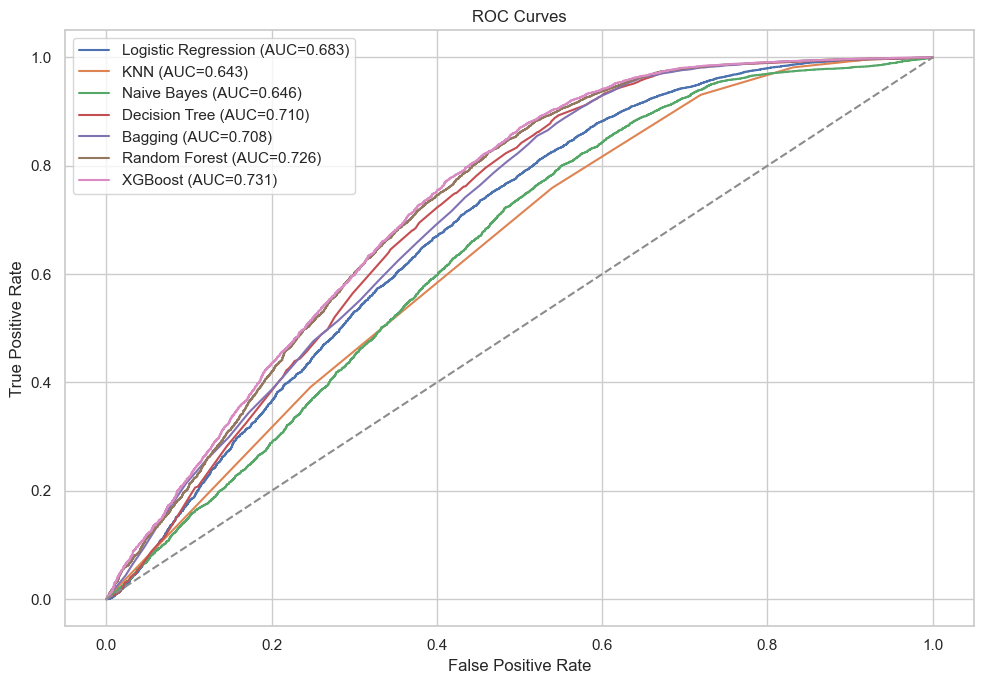

In [40]:
# Cell 40: ROC curves

from sklearn.metrics import roc_curve, auc

models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Bagging": bagging_model,
    "Random Forest": rf_model
}

if xgb_model is not None:
    models["XGBoost"] = xgb_model

plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


# 24. Cross-Validation


In [41]:
# Cell 41: Five-fold cross-validation

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("Mean CV F1", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)


,Model,Mean CV F1,Std CV F1
0,XGBoost,0.89,0.00
1,Bagging,0.89,0.00
2,Random Forest,0.88,0.00
3,Naive Bayes,0.87,0.00
4,KNN,0.86,0.00
5,Decision Tree,0.84,0.01
6,Logistic Regression,0.82,0.00


# 25. Hyperparameter Tuning

In [42]:
# Cell 42: GridSearchCV for Random Forest

from sklearn.model_selection import GridSearchCV

rf_grid_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV F1 Score: 0.8918


              precision    recall  f1-score   support

           0       0.74      0.35      0.48      4654
           1       0.83      0.96      0.89     15235

    accuracy                           0.82     19889
   macro avg       0.79      0.66      0.68     19889
weighted avg       0.81      0.82      0.79     19889



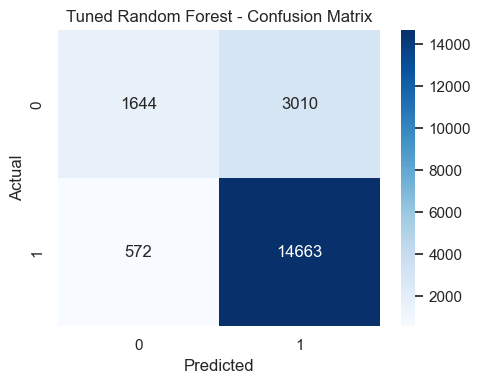

In [43]:
# Cell 43: Evaluate tuned Random Forest

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# 26. Feature Importance


,Feature,Importance
10,num__delivery_delay_days,0.20
8,num__actual_delivery_days,0.18
9,num__estimated_delivery_days,0.08
2,num__total_freight,0.08
5,num__total_payment,0.07
1,num__total_item_price,0.07
11,num__is_late,0.05
14,num__purchase_hour,0.05
12,num__purchase_month,0.04
13,num__purchase_dayofweek,0.03


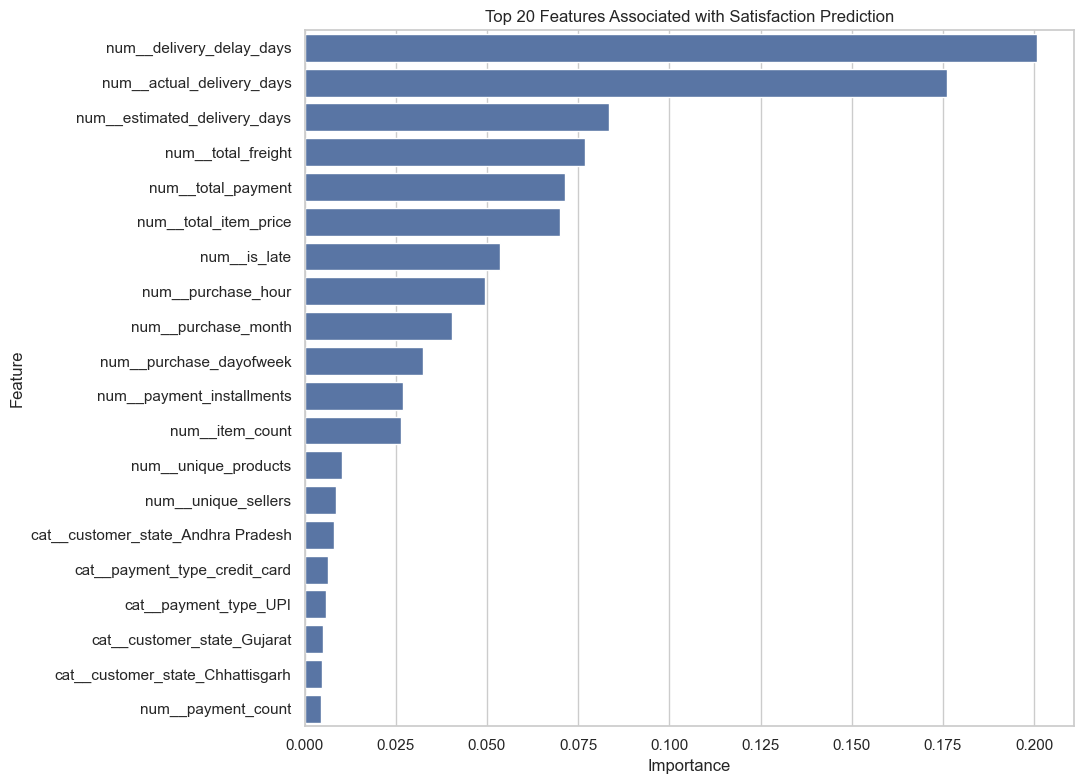

In [44]:
# Cell 44: Random Forest feature importance

best_preprocessor = best_rf.named_steps["preprocessor"]
feature_names = best_preprocessor.get_feature_names_out()
rf_classifier = best_rf.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(11, 8))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Features Associated with Satisfaction Prediction")
plt.tight_layout()
plt.show()


# 27. Generating Test-Set Predictions

In [45]:
# Cell 45: Final predictions and probabilities

final_predictions = best_rf.predict(X_test)
final_probabilities = best_rf.predict_proba(X_test)[:, 1]

prediction_results = X_test.copy()
prediction_results["Actual"] = y_test.values
prediction_results["Predicted"] = final_predictions
prediction_results["Satisfaction_Probability"] = final_probabilities

display(prediction_results.head(20))


,item_count,total_item_price,total_freight,unique_products,unique_sellers,total_payment,payment_installments,payment_count,actual_delivery_days,estimated_delivery_days,delivery_delay_days,is_late,purchase_month,purchase_dayofweek,purchase_hour,payment_type,customer_state,Actual,Predicted,Satisfaction_Probability
69213,1.00,299.00,31.50,1.00,1.00,330.50,10.00,1.00,NaN,27.36,NaN,0,11,2,15,credit_card,Jammu & Kashmir,1,0,0.22
34343,1.00,26.90,26.89,1.00,1.00,53.79,2.00,1.00,10.96,31.55,-20.59,0,6,0,10,credit_card,Andhra Pradesh,1,1,0.66
91910,1.00,219.90,36.60,1.00,1.00,256.50,4.00,1.00,12.02,26.24,-14.21,0,2,5,18,credit_card,Andhra Pradesh,1,1,0.68
41555,1.00,109.90,16.74,1.00,1.00,126.64,1.00,1.00,15.18,16.30,-1.13,0,5,0,16,UPI,Andhra Pradesh,1,1,0.59
27124,2.00,70.00,30.70,1.00,1.00,100.70,1.00,1.00,7.92,22.13,-14.21,0,6,0,20,UPI,Andhra Pradesh,1,1,0.73
86785,1.00,45.00,25.53,1.00,1.00,70.53,1.00,1.00,13.70,33.09,-19.39,0,3,1,21,credit_card,Andhra Pradesh,1,1,0.60
34598,1.00,59.90,15.52,1.00,1.00,75.42,1.00,1.00,9.34,21.49,-12.14,0,8,0,12,credit_card,Delhi,1,1,0.73
75595,1.00,69.00,7.39,1.00,1.00,76.39,1.00,1.00,1.57,14.00,-12.43,0,4,2,23,credit_card,Andhra Pradesh,1,1,0.78
40391,1.00,69.00,18.72,1.00,1.00,87.72,5.00,1.00,9.18,21.50,-12.32,0,11,6,12,credit_card,Andhra Pradesh,1,1,0.70
16196,1.00,17.90,11.85,1.00,1.00,29.75,1.00,1.00,11.94,18.08,-6.14,0,11,6,22,credit_card,Madhya Pradesh,1,1,0.65


# 28. Summary

In [50]:
# Cell 46: Generate management-facing summary from actual results

best_row = results_df.iloc[0]

total_revenue = order_items["price"].sum()
total_orders = orders["order_id"].nunique()
unique_customers = customers["customer_unique_id"].nunique()
avg_review = reviews["review_score"].mean()
satisfied_rate = ml_data["is_satisfied"].mean() * 100

top_category = category_revenue.index[0]
top_category_revenue = category_revenue.iloc[0]

top_features = feature_importance.head(5)["Feature"].tolist()

print("=" * 90)
print("EXECUTIVE MANAGEMENT SUMMARY")
print("=" * 90)

print(f'''
Business Scale
--------------
• Total item revenue analysed: {total_revenue:,.2f}
• Total orders: {total_orders:,}
• Unique customers: {unique_customers:,}
• Average review score: {avg_review:.2f} / 5
• Share of reviewed orders classified as satisfied: {satisfied_rate:.2f}%

Commercial Observation
----------------------
• Highest-revenue product category in the analysis: {top_category}
• Revenue generated by that category: {top_category_revenue:,.2f}

Predictive Modelling
--------------------
• Highest test-set F1 among the compared baseline models: {best_row["Model"]}
• Accuracy: {best_row["Accuracy"]:.3f}
• Precision: {best_row["Precision"]:.3f}
• Recall: {best_row["Recall"]:.3f}
• F1 Score: {best_row["F1 Score"]:.3f}
• ROC-AUC: {best_row["ROC-AUC"]:.3f}

Leading Model Features
----------------------
{chr(10).join("• " + x for x in top_features)}
''')


EXECUTIVE MANAGEMENT SUMMARY

Business Scale
--------------
• Total item revenue analysed: 13,591,643.70
• Total orders: 99,441
• Unique customers: 96,096
• Average review score: 4.07 / 5
• Share of reviewed orders classified as satisfied: 76.60%

Commercial Observation
----------------------
• Highest-revenue product category in the analysis: Health_Beauty
• Revenue generated by that category: 1,258,681.34

Predictive Modelling
--------------------
• Highest test-set F1 among the compared baseline models: XGBoost
• Accuracy: 0.822
• Precision: 0.826
• Recall: 0.972
• F1 Score: 0.893
• ROC-AUC: 0.731

Leading Model Features
----------------------
• num__delivery_delay_days
• num__actual_delivery_days
• num__estimated_delivery_days
• num__total_freight
• num__total_payment



# 29. Export Results


In [47]:
# Cell 47: Save manager-ready analytical outputs

results_df.to_csv("model_comparison_results.csv", index=False)
cv_results_df.to_csv("cross_validation_results.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)
prediction_results.to_csv("customer_satisfaction_predictions.csv", index=False)
monthly_sales.to_csv("monthly_sales.csv", index=False)
new_customers_monthly.to_csv("monthly_customer_acquisition.csv", index=False)

print("Report outputs exported successfully.")


Report outputs exported successfully.
